# ЛР №8

## Упражнение 8.1
___

Блокнот для этой главы — chap08.ipynb. Прочитайте его и запустите код.

В нем есть интерактивный виджет, где можно экспериментировать с параметрами гауссова окна и изучить их влияние на частоту среза.

Что случится, если при увеличении ширины гауссова окна std не увеличивать число элементов в окне M?
___
Лепестки сначала будут увеличиваться, но в какой-то момент перестанут

## Упражнение 8.2
___

In [1]:
import matplotlib.pyplot as plt

from thinkdsp.thinkdsp import *

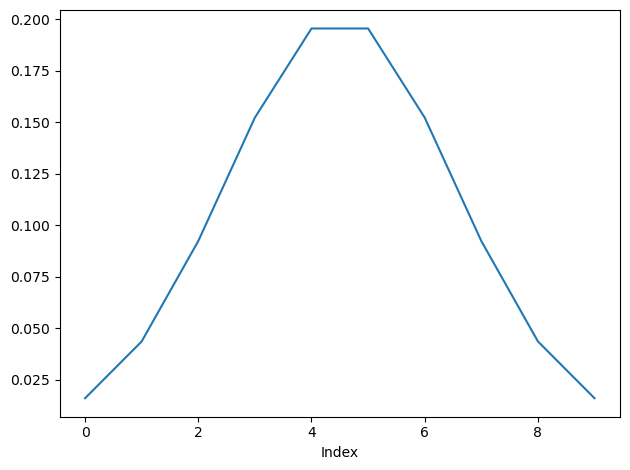

In [4]:
import scipy.signal

gaussian = scipy.signal.windows.gaussian(M=10, std=2)
gaussian /= sum(gaussian)
plt.plot(gaussian)
decorate(xlabel='Index')

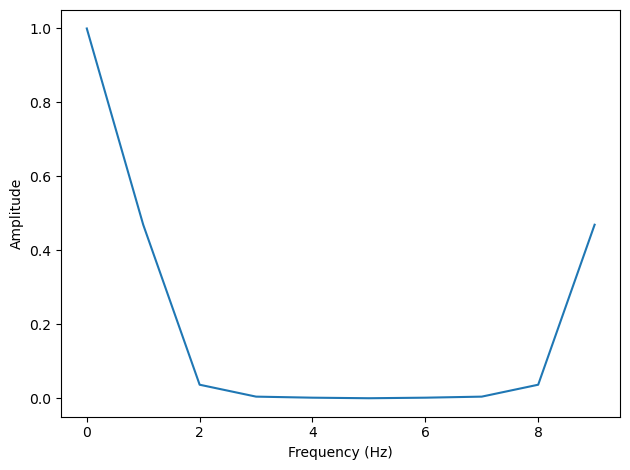

In [5]:
fft_gaussian = np.fft.fft(gaussian)
plt.plot(abs(fft_gaussian))
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

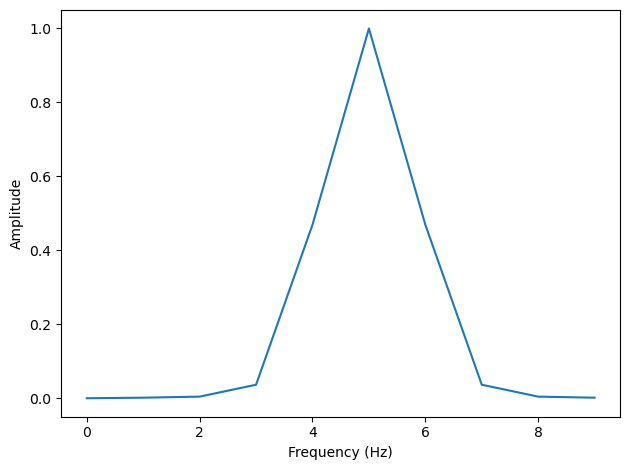

In [6]:
N = len(gaussian)
fft_rolled = np.roll(fft_gaussian, N//2)
plt.plot(abs(fft_rolled))
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

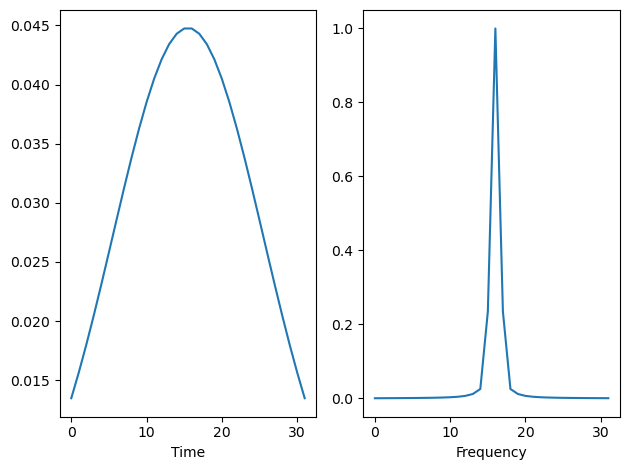

In [10]:
def plot_gaussian(std):
    M = 32
    gaussian = scipy.signal.windows.gaussian(M=M, std=std)
    gaussian /= sum(gaussian)

    plt.subplot(1, 2, 1)
    plt.plot(gaussian)
    decorate(xlabel='Time')

    fft_gaussian = np.fft.fft(gaussian)
    fft_rolled = np.roll(fft_gaussian, M//2)

    plt.subplot(1, 2, 2)
    plt.plot(np.abs(fft_rolled))
    decorate(xlabel='Frequency')
    plt.show()

plot_gaussian(10)

Если std гауссовой кривой увеличивается, то преобразование Фурье становится уже.

## Упражнение 8.3
___

In [11]:
signal = SquareSignal(freq=440)
wave = signal.make_wave(duration=1.0, framerate=44100)

In [34]:
M = 30
std = 5

barlett = np.bartlett(M)
blackman = np.blackman(M)
gauss = scipy.signal.windows.gaussian(M,std)
hamming = np.hamming(M)
hanning = np.hanning(M)

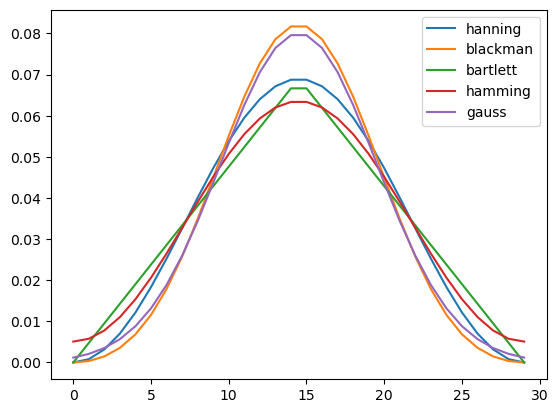

In [40]:
array  = [hanning,blackman,barlett,hamming,gauss]
labels = ['hanning','blackman','bartlett','hamming','gauss']

for elem, label in zip(array,labels):
    elem /= sum(elem)
    plt.plot(elem,label=label)
plt.legend()
plt.show()

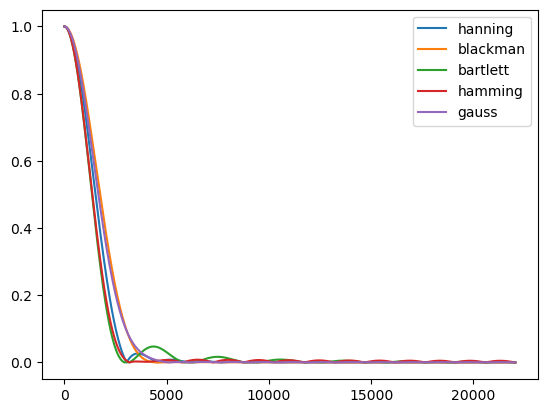

In [41]:
for elem, label in zip(array, labels):
    padded =  zero_pad(elem, len(wave))
    dft_window = np.fft.rfft(padded)
    plt.plot(abs(dft_window), label=label)
plt.legend()
plt.show()

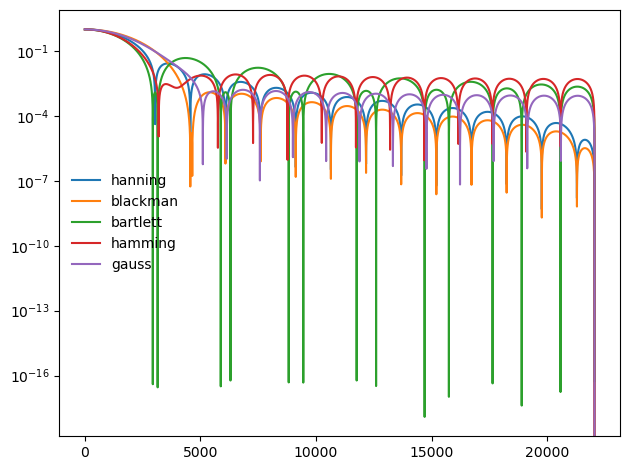

In [42]:
for elem, label in zip(array, labels):
    padded =  zero_pad(elem, len(wave))
    dft_window = np.fft.rfft(padded)
    plt.plot(abs(dft_window), label=label)
plt.legend()
decorate(yscale='log')

Смотря на логорифмический масштаб можно сделать, что Бартлет лучше всего подоёдет для фильтрации низких частот.